In [1]:
#Now, let's show how to directly edit the graph state and insert human feedback.
import os

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv())

In [2]:
#Editing state
#Previously, we introduced breakpoints.

#We used them to interrupt the graph and await user approval before executing the next node.

#But breakpoints are also opportunities to modify the graph state.

#Let's set up our agent with a breakpoint before the assistant node.
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools(tools)

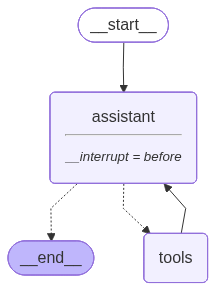

In [3]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [4]:
#We can see the graph is interrupted before the chat model responds.
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [5]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='ebe157c2-7570-4d23-8292-668016df64e4')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f135793-84de-6fca-8000-e62a19f37126'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-11T07:36:57.714264+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f135793-84dc-6356-bfff-49402a0c0486'}}, tasks=(PregelTask(id='bc4752a5-4b9d-0628-95cd-6f5afaae8561', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [6]:
#Now, we can directly apply a state update.

#Remember, updates to the messages key will use the add_messages reducer:

#If we want to over-write the existing message, we can supply the message id.
#If we simply want to append to our list of messages, then we can pass a message without an id specified, as shown below.

In [7]:
graph.update_state(
    thread,
    {"messages": [HumanMessage(content="No, actually multiply 3 and 3!")]},
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f135794-e197-6022-8001-3bb91b14bca6'}}

In [8]:
#Let's have a look.

#We called update_state with a new message.

#The add_messages reducer appends it to our state key, messages.
new_state = graph.get_state(thread).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No, actually multiply 3 and 3!


In [9]:
#Now, let's proceed with our agent, simply by passing None and allowing it proceed from the current state.

#We emit the current and then proceed to execute the remaining nodes.
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No, actually multiply 3 and 3!
================================== Ai Message ==================================
Tool Calls:
  multiply (call_Nuu9FrE8NMxjIFKLxc1MeaHF)
 Call ID: call_Nuu9FrE8NMxjIFKLxc1MeaHF
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: multiply

9


In [10]:
#Now, we're back at the assistant, which has our breakpoint.

#We can again pass None to proceed.

for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

9
================================== Ai Message ==================================

The result of multiplying 3 and 3 is 9.


In [11]:
#Studio
# This is the URL of the local development server
from langgraph_sdk import get_client
client = get_client(url="http://127.0.0.1:2024")

In [12]:
#Our agent is defined in studio/agent.py.

#If you look at the code, you'll see that it does not have a breakpoint!

#Of course, we can add it to agent.py, but one very nice feature of the API is that we can pass in a breakpoint!

#Here, we pass a interrupt_before=["assistant"]

initial_input = {"messages": "Multiply 2 and 3"}
thread = await client.threads.create()
async for chunk in client.runs.stream(
    thread["thread_id"],
    "agent",
    input=initial_input,
    stream_mode="values",
    interrupt_before=["assistant"],
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

Receiving new event of type: metadata...
--------------------------------------------------
Receiving new event of type: values...
{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': 'ae23de63-5ba8-4bcb-a879-131c6466fd7d'}
--------------------------------------------------


In [13]:
#We can get the current state
current_state = await client.threads.get_state(thread['thread_id'])
current_state

{'values': {'messages': [{'content': 'Multiply 2 and 3',
    'additional_kwargs': {},
    'response_metadata': {},
    'type': 'human',
    'name': None,
    'id': 'ae23de63-5ba8-4bcb-a879-131c6466fd7d'}]},
 'next': ['assistant'],
 'tasks': [{'id': '2ae9159e-87f0-fc92-9a3b-6b573df59bae',
   'name': 'assistant',
   'path': ['__pregel_pull', 'assistant'],
   'error': None,
   'interrupts': [],
   'checkpoint': None,
   'state': None,
   'result': None}],
 'metadata': {'graph_id': 'agent',
  'assistant_id': 'fe096781-5601-53d2-b2f6-0d3403f7e9ca',
  'user_id': '',
  'created_by': 'system',
  'run_attempt': 1,
  'langgraph_version': '1.1.4',
  'langgraph_api_version': '0.7.94',
  'langgraph_plan': 'enterprise',
  'langgraph_host': 'self-hosted',
  'langgraph_api_url': 'http://127.0.0.1:2024',
  'run_id': '019d7b81-6dc7-7781-aa08-4c330bbfc674',
  'thread_id': 'a433f368-e59e-4e81-a124-baf79bf71aa3',
  'source': 'loop',
  'step': 0,
  'parents': {},
  'langgraph_request_id': '6bfecf39-b75a-4a3

In [14]:
#We can look at the last message in state.
last_message = current_state['values']['messages'][-1]
last_message

{'content': 'Multiply 2 and 3',
 'additional_kwargs': {},
 'response_metadata': {},
 'type': 'human',
 'name': None,
 'id': 'ae23de63-5ba8-4bcb-a879-131c6466fd7d'}

In [15]:
#We can edit it!
last_message['content'] = "No, actually multiply 3 and 3!"
last_message

{'content': 'No, actually multiply 3 and 3!',
 'additional_kwargs': {},
 'response_metadata': {},
 'type': 'human',
 'name': None,
 'id': 'ae23de63-5ba8-4bcb-a879-131c6466fd7d'}

In [16]:
last_message

{'content': 'No, actually multiply 3 and 3!',
 'additional_kwargs': {},
 'response_metadata': {},
 'type': 'human',
 'name': None,
 'id': 'ae23de63-5ba8-4bcb-a879-131c6466fd7d'}

In [17]:
#Remember, as we said before, updates to the messages key will use the same add_messages reducer.

#If we want to over-write the existing message, then we can supply the message id.

#Here, we did that. We only modified the message content, as shown above.
await client.threads.update_state(thread['thread_id'], {"messages": last_message})

{'checkpoint': {'thread_id': 'a433f368-e59e-4e81-a124-baf79bf71aa3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1357ac-8850-6eec-8001-2d5dcb0706e4'},
 'configurable': {'thread_id': 'a433f368-e59e-4e81-a124-baf79bf71aa3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1357ac-8850-6eec-8001-2d5dcb0706e4'},
 'checkpoint_id': '1f1357ac-8850-6eec-8001-2d5dcb0706e4'}

In [18]:
#Now we resume by passing None
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,
    stream_mode="values",
    interrupt_before=["assistant"],
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

Receiving new event of type: metadata...
--------------------------------------------------
Receiving new event of type: values...
{'content': 'No, actually multiply 3 and 3!', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': 'ae23de63-5ba8-4bcb-a879-131c6466fd7d'}
--------------------------------------------------
Receiving new event of type: values...
{'content': '', 'additional_kwargs': {'refusal': None}, 'response_metadata': {'token_usage': {'completion_tokens': 17, 'prompt_tokens': 138, 'total_tokens': 155, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f9e6b50693', 'id': 'chatcmpl-DTNMygBSyD0nYzbw1QThL4Jz4mZcr', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, 'type': 'ai

In [19]:
#We get the tool result as 9 as expected
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,
    stream_mode="values",
    interrupt_before=["assistant"],
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

Receiving new event of type: metadata...
--------------------------------------------------
Receiving new event of type: values...
{'content': '9', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'multiply', 'id': '5ac8a9c9-b003-43c3-a8f4-7b02fcd591e4', 'tool_call_id': 'call_ynCmMbaQkQhD8EbE1AJogybn', 'artifact': None, 'status': 'success'}
--------------------------------------------------
Receiving new event of type: values...
{'content': 'The result of multiplying 3 and 3 is 9.', 'additional_kwargs': {'refusal': None}, 'response_metadata': {'token_usage': {'completion_tokens': 14, 'prompt_tokens': 163, 'total_tokens': 177, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f9e6b50693', 'id': 'chatcmpl-DTNNUXEsKggU4RFiZ

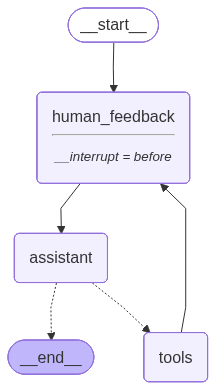

In [20]:
#Awaiting user input
#So, it's clear that we can edit our agent state after a breakpoint.

#Now, what if we want to allow for human feedback to perform this state update?

#We'll add a node that serves as a placeholder for human feedback within our agent.

#This human_feedback node allow the user to add feedback directly to state.

#We specify the breakpoint using interrupt_before our human_feedback node.

#We set up a checkpointer to save the state of the graph up until this node.
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# no-op node that should be interrupted on
def human_feedback(state: MessagesState):
    pass

# Assistant node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)

# Define edges: these determine the control flow
builder.add_edge(START, "human_feedback")
builder.add_edge("human_feedback", "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "human_feedback")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
#We will get feedback from the user.

#We use .update_state to update the state of the graph with the human response we get, as before.

#We use the as_node="human_feedback" parameter to apply this state update as the specified node, human_feedback.
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "5"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()
    
# Get user input
user_input = input("Tell me how you want to update the state: ")

# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"messages": user_input}, as_node="human_feedback")

# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


Tell me how you want to update the state:  Multiply 3 and 3


================================ Human Message =================================

Multiply 3 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_trIbDBoJmctt8wx3po6l4Zi2)
 Call ID: call_trIbDBoJmctt8wx3po6l4Zi2
  Args:
    a: 2
    b: 3
  multiply (call_e28hJI48yC9ZfiKKE6ZYR3dl)
 Call ID: call_e28hJI48yC9ZfiKKE6ZYR3dl
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: multiply

9


In [22]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

9
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6, and the result of multiplying 3 and 3 is 9.
